In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
df = pd.read_csv("benchmark_results.csv")

In [3]:
# Color palette
PHASE_COLORS = {
    "encryption": "#4C72B0",
    "addition": "#55A868",
    "decryption": "#C44E52",
    "zkp_verification": "#8172B2",
}
CAND_COLORS = {3: "#4C72B0", 5: "#55A868", 10: "#C44E52"}

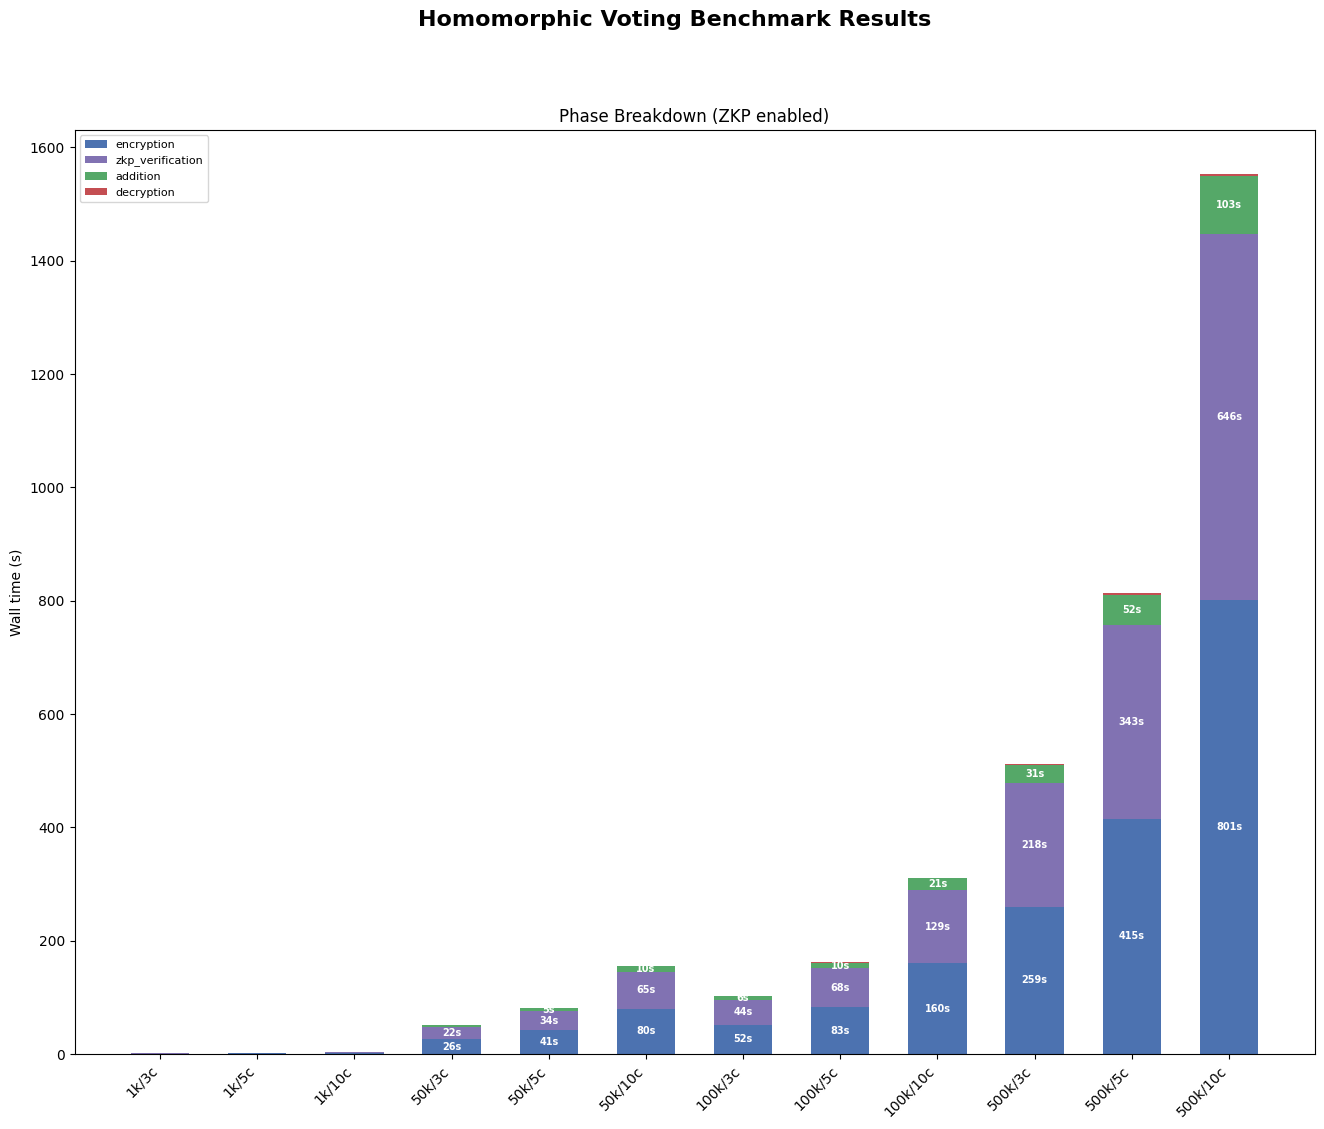

In [4]:
fig, ax = plt.subplots(figsize=(16, 12))
fig.suptitle("Homomorphic Voting Benchmark Results", fontsize=16, fontweight="bold", y=0.98)

zkp_on = df[df["zkp_enabled"] == True]
pivot = zkp_on.pivot_table(index=["ballots", "candidates"], columns="phase", values="mean_wall_s").reset_index()
labels = [f"{int(r.ballots/1000)}k/{int(r.candidates)}c" for _, r in pivot.iterrows()]
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for phase in ["encryption", "zkp_verification", "addition", "decryption"]:
    vals = pivot[phase].values
    ax.bar(x, vals, bottom=bottom, label=phase, color=PHASE_COLORS[phase], width=0.6)
    # Label large segments
    for i, v in enumerate(vals):
        if v > 5:
            ax.text(x[i], bottom[i] + v / 2, f"{v:.0f}s", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Wall time (s)")
ax.set_title("Phase Breakdown (ZKP enabled)")
ax.legend(fontsize=8)

plt.show()

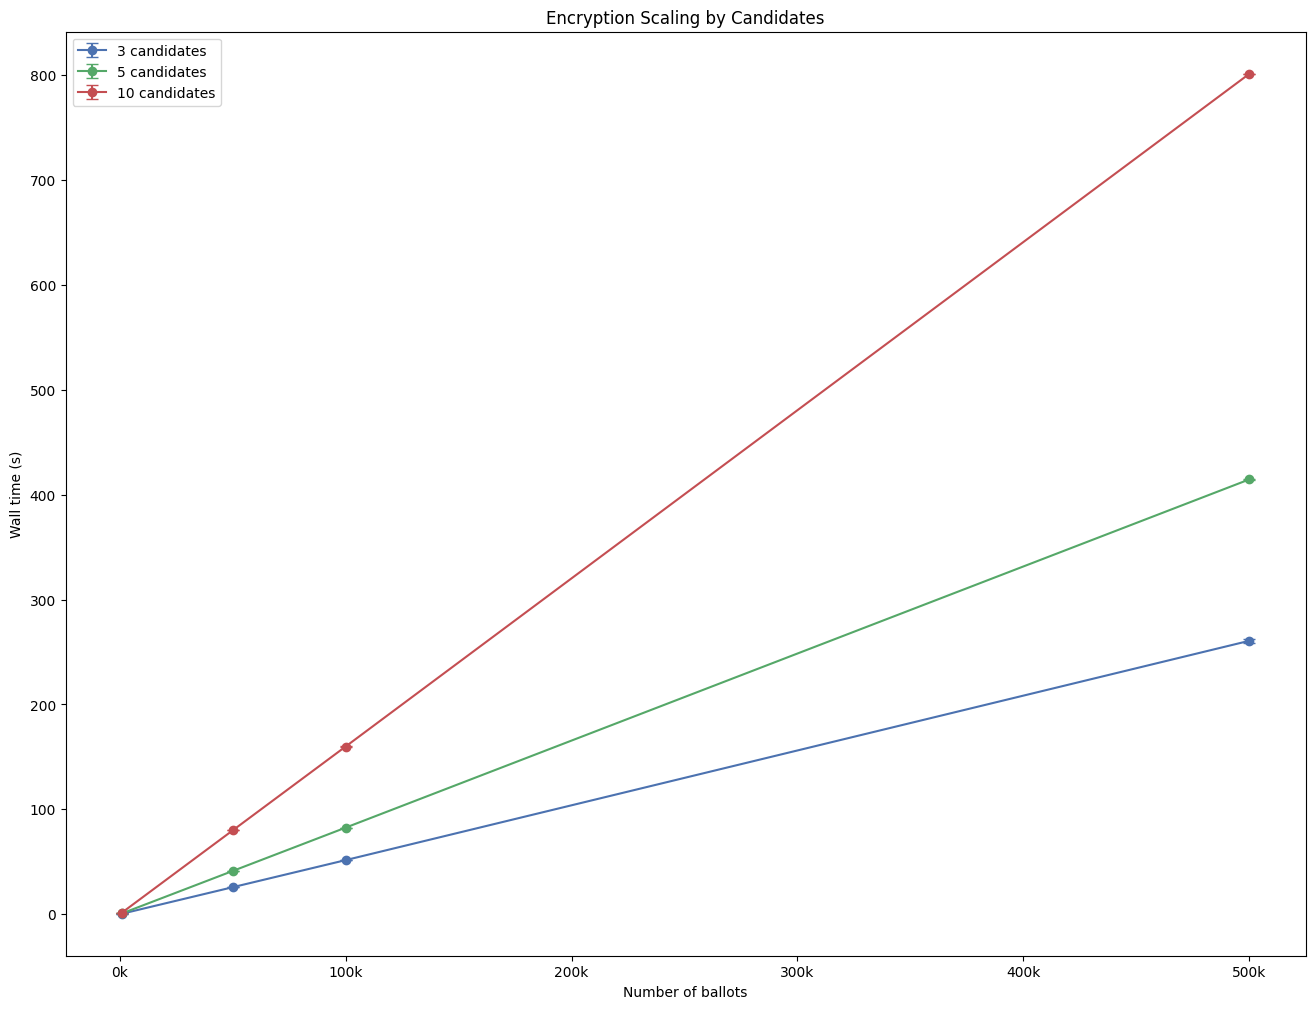

In [5]:
fig, ax = plt.subplots(figsize=(16, 12))
enc = df[(df["phase"] == "encryption") & (df["zkp_enabled"] == False)]
for c in sorted(enc["candidates"].unique()):
    sub = enc[enc["candidates"] == c].sort_values("ballots")
    ax.errorbar(sub["ballots"], sub["mean_wall_s"], yerr=sub["stddev_wall_s"],
                marker="o", label=f"{c} candidates", color=CAND_COLORS[c], capsize=4)
ax.set_xlabel("Number of ballots")
ax.set_ylabel("Wall time (s)")
ax.set_title("Encryption Scaling by Candidates")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))

plt.show()

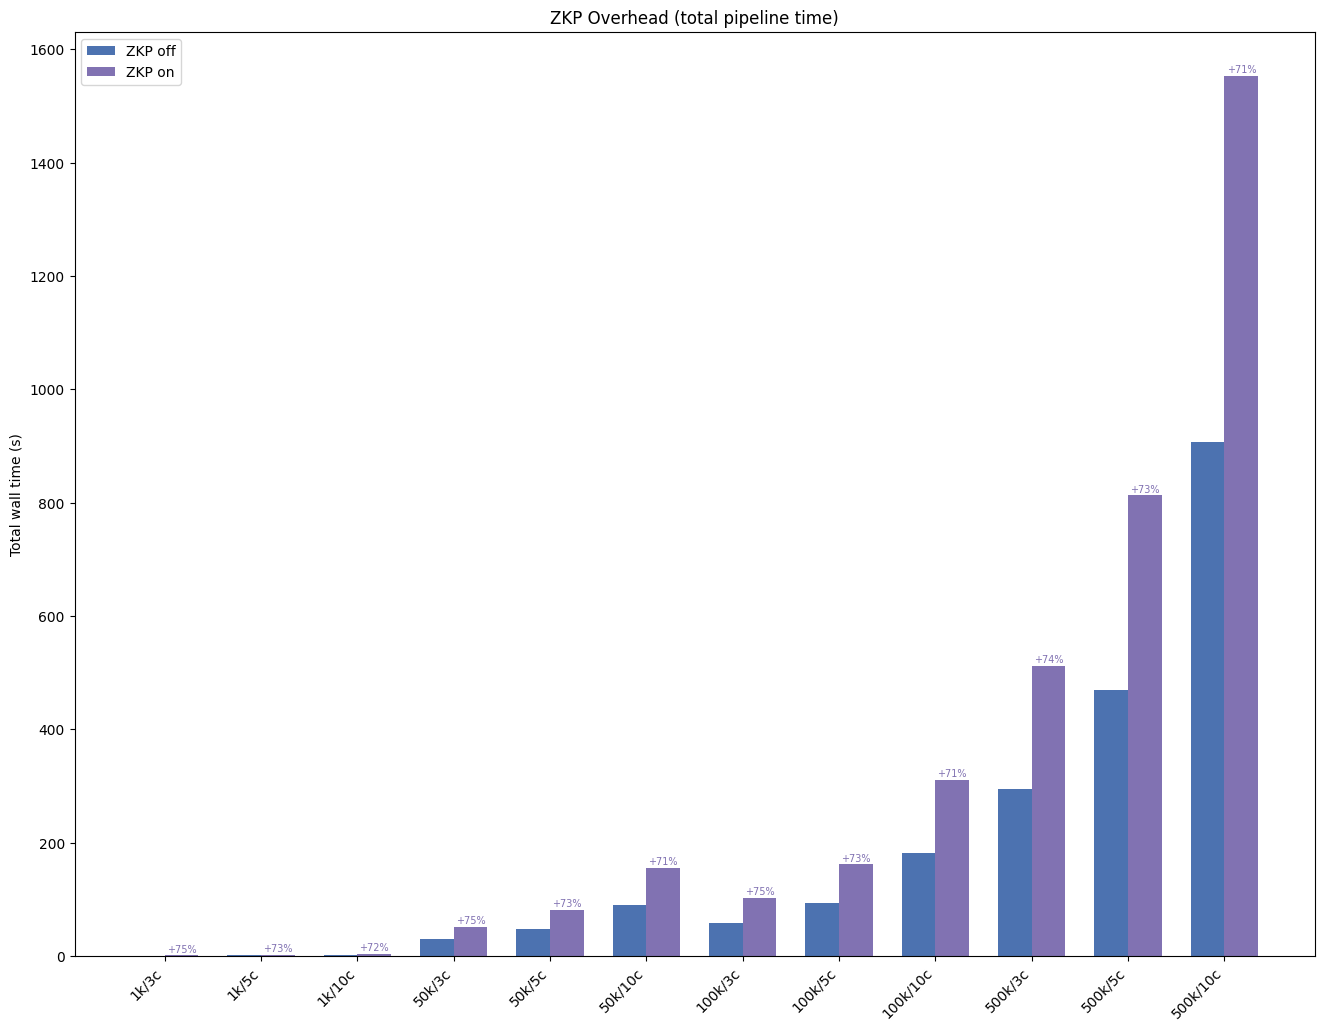

In [6]:
fig, ax = plt.subplots(figsize=(16, 12))
# Total time per config (sum of phases, excluding zkp_verification row for fair comparison of base phases)
base_phases = ["encryption", "addition", "decryption"]
totals = df[df["phase"].isin(base_phases)].groupby(["ballots", "candidates", "zkp_enabled"])["mean_wall_s"].sum().reset_index()
zkp_times = df[df["phase"] == "zkp_verification"][["ballots", "candidates", "mean_wall_s"]].rename(columns={"mean_wall_s": "zkp_time"})
merged = totals.merge(zkp_times, on=["ballots", "candidates"], how="left").fillna(0)
merged.loc[merged["zkp_enabled"] == True, "mean_wall_s"] += merged.loc[merged["zkp_enabled"] == True, "zkp_time"]

labels_all = [f"{int(r.ballots/1000)}k/{int(r.candidates)}c" for _, r in merged[merged["zkp_enabled"] == False].iterrows()]
x = np.arange(len(labels_all))
w = 0.35
off_vals = merged[merged["zkp_enabled"] == False]["mean_wall_s"].values
on_vals = merged[merged["zkp_enabled"] == True]["mean_wall_s"].values
ax.bar(x - w/2, off_vals, w, label="ZKP off", color="#4C72B0")
ax.bar(x + w/2, on_vals, w, label="ZKP on", color="#8172B2")
# Overhead percentage labels
for i in range(len(off_vals)):
    pct = (on_vals[i] - off_vals[i]) / off_vals[i] * 100
    ax.text(x[i] + w/2, on_vals[i] + 2, f"+{pct:.0f}%", ha="center", va="bottom", fontsize=7, color="#8172B2")
ax.set_xticks(x)
ax.set_xticklabels(labels_all, rotation=45, ha="right")
ax.set_ylabel("Total wall time (s)")
ax.set_title("ZKP Overhead (total pipeline time)")
ax.legend()

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
enc_mem = df[(df["phase"] == "encryption") & (df["zkp_enabled"] == False)]
for c in sorted(enc_mem["candidates"].unique()):
    sub = enc_mem[enc_mem["candidates"] == c].sort_values("ballots")
    ax.plot(sub["ballots"], sub["mean_rss_delta_kb"] / 1024, marker="s",
            label=f"{c} candidates", color=CAND_COLORS[c])
ax.set_xlabel("Number of ballots")
ax.set_ylabel("RSS delta (MB)")
ax.set_title("Memory Usage: Encryption Phase")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [16]:
ballot_base_size = 101
candidate_size = 132

candidate_count = 10
participant_count = 47_000_000

ballot = ballot_base_size + (candidate_size * candidate_count)

total_size = participant_count * ballot

print(f'Total size for an election of {participant_count} participants and {candidate_count} candidates:  {((total_size / 1024) / 1024) / 1024} GB')

Total size for an election of 47000000 participants and 10 candidates:  62.200240790843964 GB
